# Error calibration check

Fixed-cosmology cosmic-variance diagnostics: mean vs individual realizations, coverage (PP) plots, and variants that replace each realization's posterior width with alternate errors (inf-on-mean, scatter of means, scatter of MAPs).

Fiducial setup: $n_\mathrm{train}=10\,000$, $b_x=32$, noisy (`biasnoisenest`), `_best-rand30`. Full combo $P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$ unless noted.


In [1]:
import sys
import pickle
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import utils_plot
import utils_inference

%load_ext autoreload
%autoreload 2


In [2]:
# --- Fiducial config ---
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "_kpgm0.25", "_kb0.25", "_kb0.25_kpgm0.25"]
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168"]
COLOR_FULL = COLORS_FID[3]
COLOR_INDIV = "#8C8C8C"
COLOR_MAP = "black"

STAT_LABELS_SHORT = {
    "pk": r"$P_\mathrm{gg}$",
    "bispec": r"$B_\mathrm{ggg}$",
    "pgm": r"$P_\mathrm{gm}$",
}


def get_stat_label_short(statistics):
    return " + ".join(STAT_LABELS_SHORT[s] for s in statistics)


TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

TAG_PARAMS_TEST_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_TEST_COV = "_biasnoisecoverage_p9_n1000"
TAG_NOISE_TEST_COV = "_noise_unit_coverage_p5_n1000"

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
PARAM_NAMES_ZOOM = list(param_names_key)
param_names_plot = list(param_names_key)
param_label_dict = utils_plot.param_label_dict
idx_obs = 0

STATISTICS_FULL = ["pk", "bispec", "pgm"]
TAG_MASK_FULL = "_kb0.25_kpgm0.25"

EXTENTS_A = {
    "omega_cold": [0.25, 0.37],
    "sigma8_cold": [0.75, 0.88],
    "b1": [0.35, 0.60],
}
FIGSIZE_CORNER = (5, 5)

dir_sbi = paths.DIR_RESULTS / "results_sbi"
FIG_DIR = REPO_ROOT / "figures" / "2026-08-06_error_calibration_check"
FIG_DIR_LATEST = REPO_ROOT / "figures" / "error_calibration_check_latest"
OVERWRITE_FIGURES = True
FIG_EXT = "png"
CACHE_DIR = REPO_ROOT / "figures" / "paper_figures_cache"  # reuse paper MAP/PP caches
OVERWRITE_CACHE = False

names_need_rp = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]
cred_levels = np.linspace(0.0, 1.0, 51)


In [3]:
def load_or_build(name, builder, *, overwrite=None):
    if overwrite is None:
        overwrite = OVERWRITE_CACHE
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = CACHE_DIR / f"{name}.pkl"
    if path.is_file() and not overwrite:
        print(f"Loaded cache: {path}")
        with open(path, "rb") as f:
            return pickle.load(f)
    obj = builder()
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Wrote cache: {path}")
    return obj


def save_figure(fig, name, ext=FIG_EXT):
    filename = f"{name}.{ext}"
    for path in (FIG_DIR / filename, FIG_DIR_LATEST / filename):
        if path.exists() and not OVERWRITE_FIGURES:
            print(f"Skipping save (exists, overwrite=False): {filename}")
            return
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.canvas.draw_idle()
        fig.savefig(path, bbox_inches="tight", facecolor="white", edgecolor="none")
        print(f"Saved: {path}")


def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"


def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]


def setup_fiducial_inference():
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=STATISTICS_ARR_FID,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=TAGS_MASK_FID,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    labels = [get_stat_label_short(s) for s in STATISTICS_ARR_FID]
    return tags_inf, labels, list(COLORS_FID)


def setup_fixed_mean_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary



def setup_coverage_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_COV,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_COV,
        tag_datagen_test="",
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    return tags_inf, labels, colors, tags_test, keep, cosmo_vary, bias_vary, param_vary


def filter_finite_coverage_rows(theta_true_arr, theta_pred_arr, covs_pred_arr):
    """Drop coverage rows with NaN predictions (failed / timed-out inference batches)."""
    theta_true_out, theta_pred_out, covs_out = [], [], []
    for i in range(theta_pred_arr.shape[0]):
        ok = np.all(np.isfinite(theta_pred_arr[i]), axis=1)
        if covs_pred_arr.ndim == 4:
            ok &= np.all(np.isfinite(covs_pred_arr[i]).all(axis=2), axis=1)
        theta_true_out.append(theta_true_arr[i][ok])
        theta_pred_out.append(theta_pred_arr[i][ok])
        covs_out.append(covs_pred_arr[i][ok])
    return np.array(theta_true_out), np.array(theta_pred_out), np.stack(covs_out, axis=0)


def physical_from_rp(arr):
    out = np.empty_like(arr)
    out[..., 0] = arr[..., 0]
    out[..., 1] = arr[..., 1]
    out[..., 2] = arr[..., 2] / arr[..., 1]
    return out


def ranks_of_truth(samples_do, truth_o):
    """samples_do: (n_draw, n_obs); truth_o: (n_obs,) or scalar."""
    truth_o = np.asarray(truth_o, dtype=float)
    return np.mean(samples_do < truth_o[np.newaxis, ...], axis=0)


def emp_coverage(ranks, levels=None):
    levels = cred_levels if levels is None else levels
    a_min = 2.0 * np.abs(ranks[np.isfinite(ranks)] - 0.5)
    a_min.sort()
    return np.searchsorted(a_min, levels, side="right") / a_min.size


def gaussian_pp_miscal(cred, k):
    """PP curve if truth is Gaussian but reported σ = k × true σ.

    For central equal-tailed intervals:
    coverage(c) = 2 Φ(k Φ^{-1}((1+c)/2)) − 1 = erf(k · erfinv(c)).
    """
    from scipy.special import erfinv, erf
    cred = np.asarray(cred, dtype=float)
    # Φ^{-1}((1+c)/2) = √2 erfinv(c);  2Φ(kz)-1 = erf(k z/√2) = erf(k erfinv(c))
    return erf(float(k) * erfinv(cred))


def _gaussian_ref_pairs(sigma_scale_refs):
    """Group k-factors into (k_lo, k_hi) pairs for legend/styling.

    Accepts an iterable of scalars (paired lo with reciprocal-ish hi) or
    an iterable of (k_lo, k_hi) pairs. Pairs are ordered inner→outer
    (closest to 1 first).
    """
    refs = list(sigma_scale_refs)
    if not refs:
        return []
    if isinstance(refs[0], (tuple, list)) and len(refs[0]) == 2:
        pairs = [(float(a), float(b)) for a, b in refs]
    else:
        ks = sorted(float(k) for k in refs)
        los = [k for k in ks if k < 1.0]
        his = [k for k in ks if k > 1.0]
        # pair smallest lo with largest hi, etc.
        his_desc = list(reversed(his))
        n = min(len(los), len(his_desc))
        pairs = list(zip(los[:n], his_desc[:n]))
        extras = los[n:] + his_desc[n:] + [k for k in ks if k == 1.0]
        for k in extras:
            pairs.append((k, k))
    # inner (near 1) first: sort by max(|log k|) ascending
    pairs.sort(key=lambda p: max(abs(np.log(p[0])), abs(np.log(p[1]))))
    return pairs


def plot_pp_overlay(
    pp_emp, *, colors, labels, save_name=None, title_suffix=None,
    sigma_scale_refs=None, param_names=None,
):
    """pp_emp: (n_rows, n_cols, n_cred). One panel per param column.

    param_names: labels for panel titles (defaults to ``param_names_plot``).

    sigma_scale_refs: k factors or (k_lo, k_hi) pairs for dotted Gaussian
    miscalibration curves (reported σ = k × true σ). Paired reciprocals share
    one legend entry, e.g. $0.5\sigma/2\sigma$; styled dark (inner) → light (outer).
    """
    n_rows, n_cols = pp_emp.shape[0], pp_emp.shape[1]
    names = list(param_names_plot if param_names is None else param_names)
    fig, axes = plt.subplots(
        1, n_cols, figsize=(4.6 * n_cols, 3.3),
        gridspec_kw={"wspace": 0.05},
    )
    axes = np.atleast_1d(axes)
    pairs = _gaussian_ref_pairs(sigma_scale_refs) if sigma_scale_refs is not None else []
    # dark inside → light outside
    if pairs:
        greys = np.linspace(0.15, 0.65, len(pairs))

    for c in range(n_cols):
        ax = axes[c]
        ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.7, zorder=1)
        for i_p, (k_lo, k_hi) in enumerate(pairs):
            grey = str(greys[i_p])
            lab = None
            if c == 0:
                if np.isclose(k_lo, k_hi):
                    lab = rf"Gaussian ${k_lo:g}\sigma$"
                else:
                    lab = rf"Gaussian ${k_lo:g}\sigma/{k_hi:g}\sigma$"
            for k in dict.fromkeys((k_lo, k_hi)):  # unique, keep order
                ax.plot(
                    cred_levels, gaussian_pp_miscal(cred_levels, k),
                    color=grey, lw=0.8, ls=":",
                    label=lab,
                    zorder=1.5,
                )
                lab = None  # only first curve of the pair gets the legend handle
        for r in range(n_rows):
            ax.plot(
                cred_levels, pp_emp[r, c],
                color=colors[r], lw=1.5,
                label=labels[r] if c == 0 else None,
                zorder=2,
            )
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks(np.arange(0, 1.01, 0.1))
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("credibility level", fontsize=12)
        ax.set_ylabel("empirical coverage", fontsize=12, labelpad=2.5)
        if c == 0:
            ax.legend(fontsize=9, loc="best", frameon=False, labelcolor="black")
        title = rf"{param_label_dict[names[c]]}"
        if title_suffix:
            title = rf"{title} {title_suffix}"
        ax.set_title(title, fontsize=15, fontweight="bold")
    plt.tight_layout(w_pad=1.0)
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()
    # Do not return fig: Jupyter would display it again after plt.show().


def gaussian_rank_samples(centers, sigma, n_draw=5000, rng=None):
    """Synthetic (n_draw, n_obs) samples ~ N(centers, sigma^2) for rank coverage."""
    rng = np.random.default_rng(0) if rng is None else rng
    centers = np.asarray(centers, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    noise = rng.normal(0.0, 1.0, size=(n_draw, centers.size))
    return centers[None, :] + sigma * noise


def recentre_template(template_samples, centers):
    """Broadcast template (n_draw, n_par) to (n_draw, n_obs, n_par) centred at centers."""
    template_samples = np.asarray(template_samples, dtype=float)
    centers = np.asarray(centers, dtype=float)
    t_mean = np.nanmean(template_samples, axis=0)
    return template_samples[:, None, :] - t_mean[None, None, :] + centers[None, :, :]


## Shared data — fixed-cosmo full combo

Load once: individual-realization posteriors, mean-of-stats posterior, truth, and cached MAPs.


In [4]:
# Tags + loads for Pgg+Bggg+Pgm fixed-cosmo suite
tags_inf_row, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN, tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=[STATISTICS_FULL], bx=bx, tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam, n_train=n_train, tags_mask=[TAG_MASK_FULL],
)
tag_inf_full = tags_inf_row[0] + TAG_INF_BEST_SUFFIX
tag_stats_full = f'_{"_".join(STATISTICS_FULL)}'
tag_test_mean = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats_full],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
    tags_mask_test=[TAG_MASK_FULL],
)[0]
tag_test_sample = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats_full],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test="",
    tags_mask_test=[TAG_MASK_FULL],
)[0]

fn_sample = sample_fn(tag_inf_full, tag_test_sample)
fn_mean = sample_fn(tag_inf_full, tag_test_mean)
for fn in (fn_sample, fn_mean):
    if not fn.exists():
        raise FileNotFoundError(fn)
print(f"fn_samples (indiv) = {fn_sample}")
print(f"fn_samples (mean)  = {fn_mean}")

samples_arr = np.load(fn_sample)  # (n_draw, n_obs, n_par)
samples_mean = np.load(fn_mean)
param_names_samples = np.loadtxt(dir_sbi / f"sbi{tag_inf_full}" / "param_names.txt", dtype=str)
if samples_mean.ndim == 3:
    samples_mean = samples_mean[:, 0, :]

samples_u, names_u = utils_inference.unreparameterize_theta(
    samples_arr, list(param_names_samples), strict=False,
)
names_u = list(names_u)
i_zoom = [names_u.index(pn) for pn in PARAM_NAMES_ZOOM]
samples_zoom = samples_u[:, :, i_zoom]  # (n_draw, n_obs, n_zoom)

theta_hat = np.nanmean(samples_zoom, axis=0)
finite_obs = np.all(np.isfinite(theta_hat), axis=1)
theta_hat = theta_hat[finite_obs]
samples_zoom_ok = samples_zoom[:, finite_obs, :]
sigma_hat_i = np.nanstd(samples_zoom_ok, axis=0)
n_obs_ok = theta_hat.shape[0]
print(f"finite realizations: {n_obs_ok}/{samples_arr.shape[1]}")


def _build_fixed_cosmo_maps():
    theta_map = np.empty((n_obs_ok, len(PARAM_NAMES_ZOOM)), dtype=float)
    for i in range(n_obs_ok):
        if (i + 1) % 100 == 0 or i == 0:
            print(f"  MAP {i + 1}/{n_obs_ok}")
        theta_map[i] = utils_inference.get_posterior_maxes(
            samples_zoom_ok[:, i, :], list(PARAM_NAMES_ZOOM), n_grid=500,
        )
    return theta_map


theta_map = load_or_build(
    "figA_fixedcosmo_posterior_maps_pk_bispec_pgm",
    _build_fixed_cosmo_maps,
)

samples_mean_u, names_mean_u = utils_inference.unreparameterize_theta(
    samples_mean, list(param_names_samples), strict=False,
)
names_mean_u = list(names_mean_u)
i_zoom_m = [names_mean_u.index(pn) for pn in PARAM_NAMES_ZOOM]
samples_mean_zoom = samples_mean_u[:, i_zoom_m]
theta_mean_stat = np.nanmean(samples_mean_zoom, axis=0)
sigma_mean_stat = np.nanstd(samples_mean_zoom, axis=0)

_, _, _, _, _, _, theta_true, _ = setup_fixed_mean_test()
theta_true = np.asarray(theta_true, dtype=float)

sigma_means_dist = np.nanstd(theta_hat, axis=0, ddof=1)  # scatter of posterior means
sigma_maps_dist = np.nanstd(theta_map, axis=0, ddof=1)    # scatter of MAPs
print("σ_meanstat:", sigma_mean_stat)
print("σ(means):  ", sigma_means_dist)
print("σ(MAPs):   ", sigma_maps_dist)


fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
fn_samples (mean)  = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
finite realizations: 1000/1000
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA_fixedcosmo_posterior_maps_pk_bispec_pgm.pkl
σ_meanstat: [0.01462746 0.01214588 0.0186292 ]
σ(means):   [0.01212296 0.00993055 0.01120348]
σ(MAPs):    [0.01216167 0.00999474 0.01018123]


## a. Mean vs individual realization contours

Mean-of-stats posterior (filled) plus $n_\mathrm{plot}$ random individual realization posteriors (thin grey).


overplotting 10 individual posteriors (idxs=[16, 40, 75, 175, 268, 306, 507, 631, 813, 842])
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_a_mean_vs_indiv_contours.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_a_mean_vs_indiv_contours.png


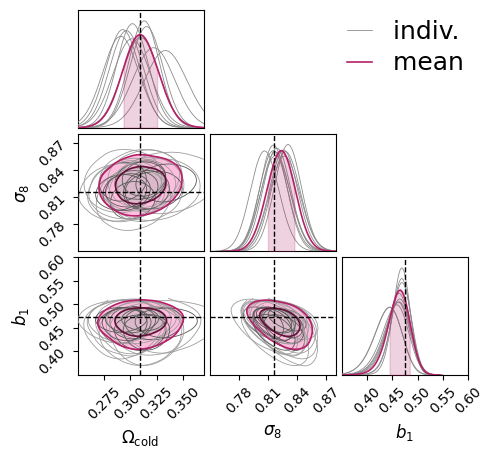

In [5]:
# a: mean-of-stats + random individual realization contours
# Pass reparameterized samples so plotter.unreparameterize=True matches paper notebook.
n_plot = 10
lw_indiv, lw_mean = 0.6, 1.2
rng_a1 = np.random.default_rng(0)

finite_idxs = np.flatnonzero(finite_obs)
idxs_obs = rng_a1.choice(finite_idxs, size=min(n_plot, finite_idxs.size), replace=False)
print(f"overplotting {len(idxs_obs)} individual posteriors (idxs={np.sort(idxs_obs).tolist()})")

samples_list = [
    (samples_arr[:, i, :], list(param_names_samples)) for i in idxs_obs
] + [None]
n_use = len(idxs_obs)
tags_test_a1 = [None] * n_use + [tag_test_mean]
tags_inf_a1 = [tag_inf_full] * (n_use + 1)
colors_a1 = [COLOR_INDIV] * n_use + [COLOR_FULL]
labels_a1 = ["indiv."] + [f"indiv. {j}" for j in range(1, n_use)] + ["mean"]
shades_a1 = [False] * n_use + [True]
show_labels_a1 = [True] + [False] * (n_use - 1) + [True]
linewidths_a1 = [lw_indiv] * n_use + [lw_mean]

fig = plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_true,
    inf_methods=["sbi"] * (n_use + 1),
    tags_inf=tags_inf_a1,
    tags_test=tags_test_a1,
    colors=colors_a1,
    labels=labels_a1,
    shades=shades_a1,
    show_label_in_legend=show_labels_a1,
    linewidths=linewidths_a1,
    title=None,
    extents=EXTENTS_A,
    figsize=FIGSIZE_CORNER,
    unreparameterize=True,
    samples_list=samples_list,
    show=False,
)
if fig is not None:
    save_figure(fig, "fig_a_mean_vs_indiv_contours")
plt.show()


## b. Mean contours vs contours of per-realization means & MAPs

1σ/2σ contours of the distribution of posterior means (grey) and MAPs (black) across all realizations, vs inference on the mean of the statistics.


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_b_mean_vs_means_and_maps_contours.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_b_mean_vs_means_and_maps_contours.png


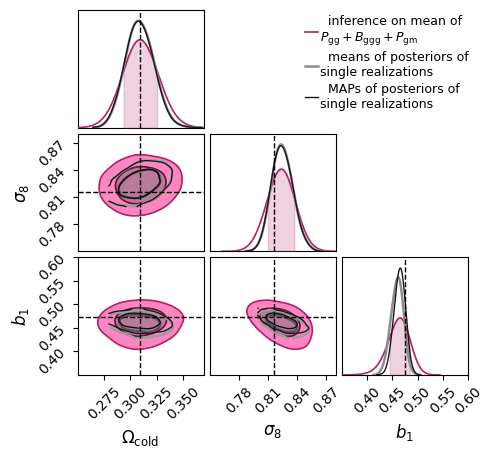

In [6]:
# b: mean-of-stats vs contours of posterior means & MAPs
label_mean = "inference on mean of\n$P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$"
label_indiv = "means of posteriors of\nsingle realizations"
label_maps = "MAPs of posteriors of\nsingle realizations"

fig = plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_true,
    inf_methods=["sbi", "sbi", "sbi"],
    tags_inf=[tag_inf_full, tag_inf_full, tag_inf_full],
    tags_test=[tag_test_mean, None, None],
    colors=[COLOR_FULL, COLOR_INDIV, COLOR_MAP],
    labels=[label_mean, label_indiv, label_maps],
    shades=[True, False, False],
    linewidths=[1.2, 1.8, 1.0],
    fontsize_legend=9,
    title=None,
    extents=EXTENTS_A,
    figsize=FIGSIZE_CORNER,
    unreparameterize=True,
    samples_list=[
        None,
        (theta_hat, list(PARAM_NAMES_ZOOM)),
        (theta_map, list(PARAM_NAMES_ZOOM)),
    ],
    show=False,
)
if fig is not None:
    save_figure(fig, "fig_b_mean_vs_means_and_maps_contours")
plt.show()


## c. Bias check: recentred single-realization uncertainty

Shift each realization's posterior so its mean moves to the group mean $\bar\theta$, then pool. Contours show bias location at typical single-realization width.


pooled recentred samples: 500000 (n_obs=1000 × k=500)
bias-check location vs truth:
  omega_cold:  θ̄−true=+0.0003043,  SE=0.0003834,  z=+0.794
  sigma8_cold:  θ̄−true=+0.00887,  SE=0.000314,  z=+28.2
  b1:  θ̄−true=-0.01487,  SE=0.0003543,  z=-42
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_c_biascheck_recentred_contours.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_c_biascheck_recentred_contours.png


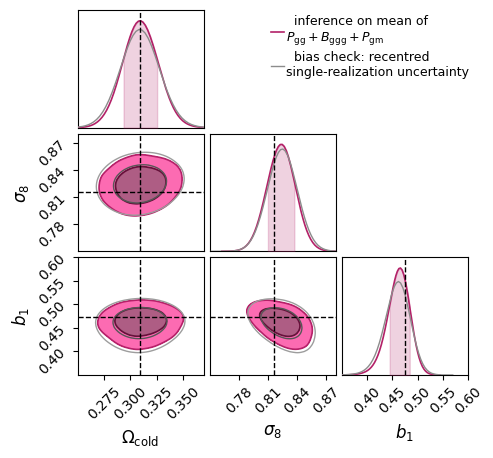

In [7]:
# c: pooled posteriors recentred to group mean
k_per_obs = 500
rng_a1c = np.random.default_rng(1)

theta_bar = np.mean(theta_hat, axis=0)
n_draw = samples_zoom_ok.shape[0]
k = min(int(k_per_obs), n_draw)
draw_idx = rng_a1c.choice(n_draw, size=k, replace=False)
s_tilde = samples_zoom_ok[draw_idx] - theta_hat[None, :, :] + theta_bar[None, None, :]
pooled = s_tilde.reshape(k * n_obs_ok, len(PARAM_NAMES_ZOOM))
print(f"pooled recentred samples: {pooled.shape[0]} (n_obs={n_obs_ok} × k={k})")

SE = np.std(theta_hat, axis=0, ddof=1) / np.sqrt(n_obs_ok)
z_bias = (theta_bar - theta_true) / SE
print("bias-check location vs truth:")
for j, pn in enumerate(PARAM_NAMES_ZOOM):
    print(
        f"  {pn}:  θ̄−true={theta_bar[j] - theta_true[j]:+.4g},  "
        f"SE={SE[j]:.4g},  z={z_bias[j]:+.3g}"
    )

fig = plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_true,
    inf_methods=["sbi", "sbi"],
    tags_inf=[tag_inf_full, tag_inf_full],
    tags_test=[tag_test_mean, None],
    colors=[COLOR_FULL, COLOR_INDIV],
    labels=[
        "inference on mean of\n$P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$",
        "bias check: recentred\nsingle-realization uncertainty",
    ],
    shades=[True, False],
    linewidths=[1.2, 1.0],
    fontsize_legend=9,
    title=None,
    extents=EXTENTS_A,
    figsize=FIGSIZE_CORNER,
    unreparameterize=True,
    samples_list=[None, (pooled, list(PARAM_NAMES_ZOOM))],
    show=False,
)
if fig is not None:
    save_figure(fig, "fig_c_biascheck_recentred_contours")
plt.show()


## d. PP plot — cosmic variance (fixed cosmology)

Nominal credibility vs empirical coverage using each realization's own posterior (all four fiducial statistic combinations).


PP cosmic variance: 1/4 combos with samples
fixed truth (Ωc, σ8, b1) = [0.3089     0.8159     0.47410742]
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA1d_pp_emp_arr.pkl


/tmp/ipykernel_3626161/1846916356.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=1.0)


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_d_cosmic_variance_pp.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_d_cosmic_variance_pp.png


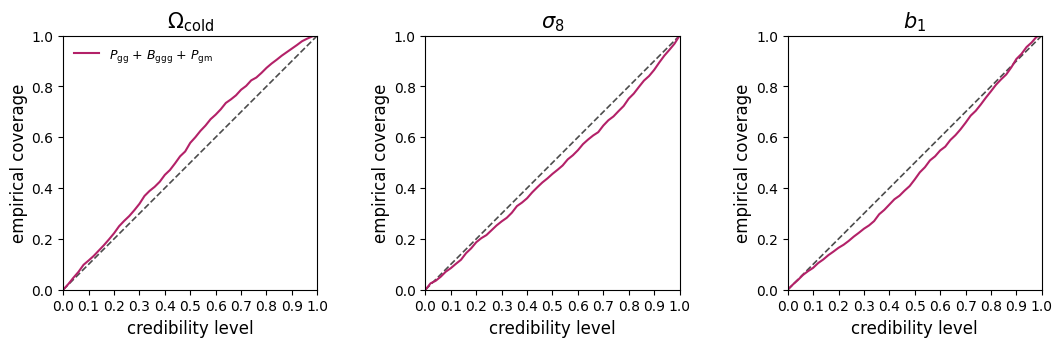

In [8]:
# d: standard PP — each realization's own posterior
tags_inf_a1d, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=STATISTICS_ARR_FID,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=TAGS_MASK_FID,
)
tags_inf_a1d = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_a1d]
tag_stats_a1d = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
tags_test_a1d = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
    tag_stats_arr=tag_stats_a1d,
    tag_noise_test=TAG_NOISE_TEST_FIXED,
    tag_datagen_test="",
    tags_mask_test=TAGS_MASK_FID,
)
keep_a1d = samples_exist(tags_inf_a1d, tags_test_a1d)
tags_inf_a1d_ok = [tags_inf_a1d[i] for i, k in enumerate(keep_a1d) if k]
tags_test_a1d_ok = [tags_test_a1d[i] for i, k in enumerate(keep_a1d) if k]
colors_a1d_ok = [COLORS_FID[i] for i, k in enumerate(keep_a1d) if k]
labels_a1d_ok = [get_stat_label_short(STATISTICS_ARR_FID[i]) for i, k in enumerate(keep_a1d) if k]
n_rows_a1d = len(tags_inf_a1d_ok)
n_cols_a1d = len(param_names_plot)
print(f"PP cosmic variance: {n_rows_a1d}/{len(STATISTICS_ARR_FID)} combos with samples")

cosmo_vary_a1d, bias_vary_a1d, param_vary_a1d = utils_plot.load_training_params(
    TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
)
theta_fixed = data_loader.load_theta_test(
    TAG_PARAMS_TEST_FIXED,
    TAG_BIASPARAMS_TEST_FIXED,
    cosmo_param_names_vary=cosmo_vary_a1d,
    bias_param_names_vary=bias_vary_a1d,
)
theta_fixed_2d = np.atleast_2d(np.asarray(theta_fixed, dtype=float))
if tag_reparam:
    theta_fixed_rp, names_theta_a1d = utils_inference.reparameterize_theta(
        theta_fixed_2d, list(param_vary_a1d),
    )
else:
    theta_fixed_rp, names_theta_a1d = theta_fixed_2d, list(param_vary_a1d)
names_theta_a1d = list(names_theta_a1d)
i_t_a1d = [names_theta_a1d.index(pn) for pn in names_need_rp]
theta_phys_fixed = physical_from_rp(theta_fixed_rp[0, i_t_a1d])
print(f"fixed truth (Ωc, σ8, b1) = {theta_phys_fixed}")


def _load_key_samples(tag_inf, tag_test):
    dir_run = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}"
    fn = dir_run / f"samples_test{tag_test}_pred.npy"
    names_samp = list(np.loadtxt(dir_run / "param_names.txt", dtype=str))
    idxs = [names_samp.index(pn) for pn in names_need_rp]
    mm = np.load(fn, mmap_mode="r")
    if mm.ndim == 2:
        return np.asarray(mm[:, idxs], dtype=np.float64)[:, None, :]
    return np.asarray(mm[:, :, idxs], dtype=np.float64)


def _build_figA1d_pp_emp():
    pp = np.full((n_rows_a1d, n_cols_a1d, cred_levels.size), np.nan)
    for r in range(n_rows_a1d):
        samples_rp = _load_key_samples(tags_inf_a1d_ok[r], tags_test_a1d_ok[r])
        ok = np.all(np.isfinite(samples_rp.mean(axis=0)), axis=1)
        print(f"  {labels_a1d_ok[r]}: {np.count_nonzero(ok)}/{ok.size} usable")
        samples_phys = physical_from_rp(samples_rp[:, ok, :])
        n_ok = int(np.count_nonzero(ok))
        for c in range(n_cols_a1d):
            truth_c = np.full(n_ok, theta_phys_fixed[c])
            pp[r, c] = emp_coverage(ranks_of_truth(samples_phys[:, :, c], truth_c))
    return pp


pp_emp_a1d = load_or_build("figA1d_pp_emp_arr", _build_figA1d_pp_emp)
plot_pp_overlay(
    pp_emp_a1d,
    colors=colors_a1d_ok,
    labels=labels_a1d_ok,
    save_name="fig_d_cosmic_variance_pp",
)


## e. Per-realization posterior means, MAPs & widths vs SBI-on-mean

Top: per-realization means (grey) and MAPs (black) relative to truth, plus full SBI-on-mean posterior (purple). Bottom: per-realization posterior widths.


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_e_posterior_means_and_widths_vs_meanstat.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_e_posterior_means_and_widths_vs_meanstat.png


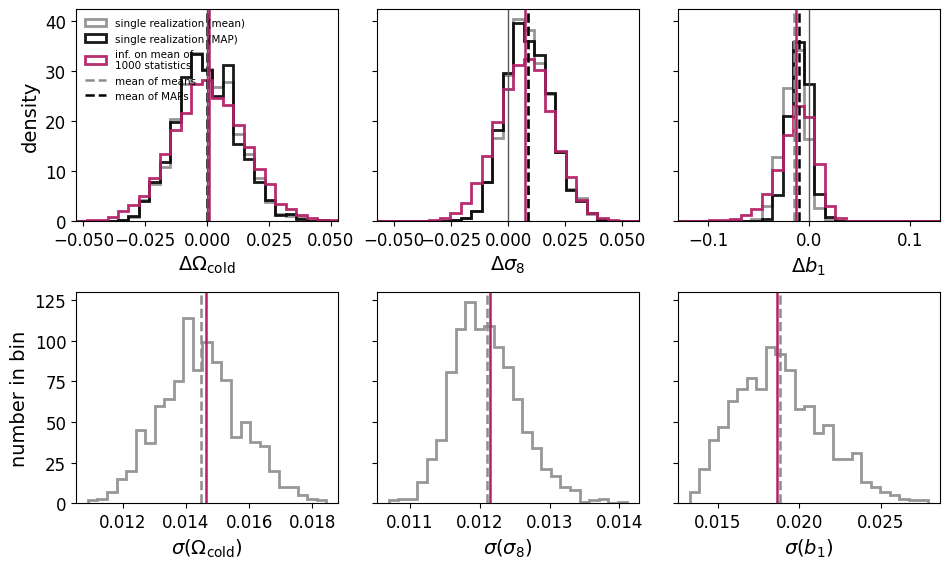

In [9]:
# e: histograms of means / MAPs / widths vs mean-stat
n_bins_a2 = 25
labelsize_a2 = 14
lw_hist = 2.0

delta_hat = theta_hat - theta_true[None, :]
delta_map = theta_map - theta_true[None, :]
delta_hat_bar = np.nanmean(delta_hat, axis=0)
delta_map_bar = np.nanmean(delta_map, axis=0)
delta_mean_stat = theta_mean_stat - theta_true
sigma_hat_bar = np.nanmean(sigma_hat_i, axis=0)
delta_mean_samples = samples_mean_zoom - theta_true[None, :]

labels_tex = [utils_plot.param_label_dict.get(pn, pn) for pn in PARAM_NAMES_ZOOM]
n_par = len(PARAM_NAMES_ZOOM)

fig, axes = plt.subplots(2, n_par, figsize=(3.2 * n_par, 5.8), sharey="row")
for j in range(n_par):
    ax_m, ax_s = axes[0, j], axes[1, j]
    lab_inner = labels_tex[j].strip("$")
    show_leg = j == 0

    xmax = np.nanmax(np.abs(np.concatenate([
        delta_hat[:, j], delta_map[:, j], delta_mean_samples[:, j],
    ])))
    bins_m = np.linspace(-xmax, xmax, n_bins_a2 + 1)
    ax_m.hist(delta_hat[:, j], bins=bins_m, histtype="step",
              color=COLOR_INDIV, lw=lw_hist, alpha=0.9, density=True,
              label="single realization (mean)" if show_leg else None)
    ax_m.hist(delta_map[:, j], bins=bins_m, histtype="step",
              color=COLOR_MAP, lw=lw_hist, alpha=0.9, density=True,
              label="single realization (MAP)" if show_leg else None)
    ax_m.hist(delta_mean_samples[:, j], bins=bins_m, histtype="step",
              color=COLOR_FULL, lw=lw_hist, alpha=0.95, density=True,
              label="inf. on mean of\n1000 statistics" if show_leg else None)
    ax_m.axvline(delta_hat_bar[j], color=COLOR_INDIV, lw=1.8, ls="--",
                 label="mean of means" if show_leg else None)
    ax_m.axvline(delta_map_bar[j], color=COLOR_MAP, lw=1.8, ls="--",
                 label="mean of MAPs" if show_leg else None)
    ax_m.axvline(delta_mean_stat[j], color=COLOR_FULL, lw=1.8, ls="-")
    ax_m.axvline(0.0, color="0.35", lw=1.0)
    ax_m.set_xlabel(rf"$\Delta${labels_tex[j]}", fontsize=labelsize_a2)
    ax_m.tick_params(labelsize=12)
    ax_m.set_xlim(-xmax, xmax)

    ax_s.hist(sigma_hat_i[:, j], bins=n_bins_a2, histtype="step",
              color=COLOR_INDIV, lw=lw_hist, alpha=0.9)
    ax_s.axvline(sigma_hat_bar[j], color=COLOR_INDIV, lw=1.8, ls="--")
    ax_s.axvline(sigma_mean_stat[j], color=COLOR_FULL, lw=1.8)
    ax_s.set_xlabel(rf"$\sigma({lab_inner})$", fontsize=labelsize_a2)
    ax_s.tick_params(labelsize=12)

axes[0, 0].set_ylabel("density", fontsize=labelsize_a2)
axes[1, 0].set_ylabel("number in bin", fontsize=labelsize_a2)
axes[0, 0].legend(fontsize=7.5, loc="upper left", frameon=False, labelcolor="black")
fig.tight_layout()
save_figure(fig, "fig_e_posterior_means_and_widths_vs_meanstat")
plt.show()


## f. Posterior width vs offset from truth

Scatter of posterior $\sigma_i$ vs $\Delta\theta_i=\hat\theta_i-\theta_{\mathrm{true}}$ for $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$: **coverage** test set (pink) and **cosmic-variance** fixed-cosmo mocks (blue). Horizontal lines mark mean $\sigma$ for each set; vertical line is $\Delta=0$.

Second panel: cosmic-variance mocks alone.


Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/fig4_coverage_arrays.pkl
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_f_sigma_vs_delta_cov_cv.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_f_sigma_vs_delta_cov_cv.png


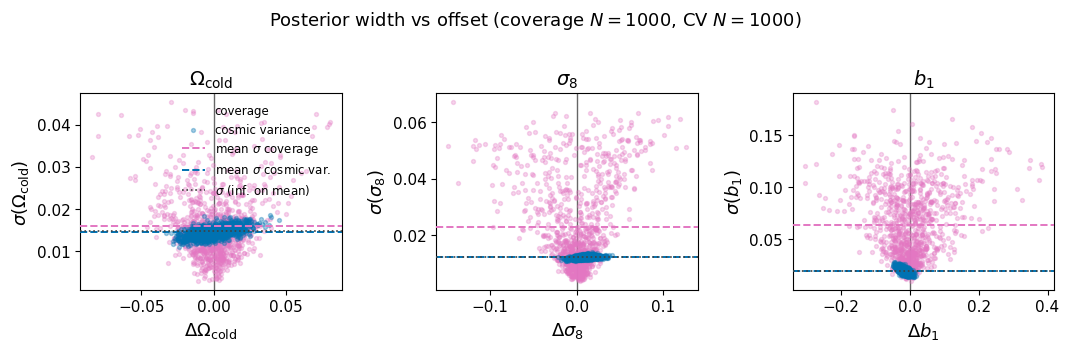

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_f_sigma_vs_delta_cv_only.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_f_sigma_vs_delta_cv_only.png


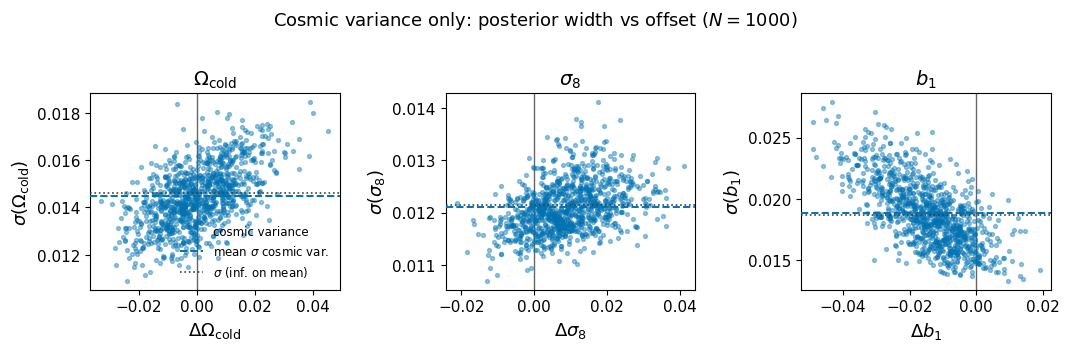

coverage n=1000, CV n=1000
  omega_cold:  cov median|Δ|=0.011, median σ=0.01457;  CV median|Δ|=0.008473, median σ=0.0144
  sigma8_cold:  cov median|Δ|=0.01296, median σ=0.0169;  CV median|Δ|=0.009026, median σ=0.01206
  b1:  cov median|Δ|=0.03615, median σ=0.05807;  CV median|Δ|=0.01416, median σ=0.0186


In [10]:
# f: σ vs Δ — coverage (pink) + cosmic variance (blue)
color_cov = "#E377C2"  # pink
color_cv = "#0072B2"   # blue

# Coverage arrays (reuse fig4 cache; builder may already exist from later cells)
idx_full = STATISTICS_ARR_FID.index(STATISTICS_FULL)


def _build_fig4_coverage_arrays_f():
    tags_inf, _, _, tags_test, keep, cosmo_vary, bias_vary, param_vary = setup_coverage_test()
    tags_test_ok = [tags_test[i] for i, k in enumerate(keep) if k]
    tags_inf_ok = [tags_inf[i] for i, k in enumerate(keep) if k]
    stats_ok = [STATISTICS_ARR_FID[i] for i, k in enumerate(keep) if k]
    theta_true_arr, theta_pred_arr, _, covs_pred_arr, _ = utils_plot.load_test_predictions(
        tags_inf=tags_inf_ok,
        tags_data_test=tags_test_ok,
        tag_params_test=TAG_PARAMS_TEST_COV,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
        param_names_vary=param_vary,
        tag_reparam=tag_reparam,
        param_names_show=param_names_key_rp,
    )
    theta_true_arr, theta_pred_arr, covs_pred_arr = filter_finite_coverage_rows(
        theta_true_arr, theta_pred_arr, covs_pred_arr,
    )
    theta_pred_u = theta_pred_arr.copy()
    theta_true_u = theta_true_arr.copy()
    covs_u = covs_pred_arr.copy()
    names_u = list(param_names_key_rp)
    for r in range(len(stats_ok)):
        tp, tt, covs, names_u = utils_inference.unreparameterize_prediction_block(
            theta_pred_u[r], theta_true_u[r], list(param_names_key_rp), covs_u[r],
        )
        theta_pred_u[r], theta_true_u[r], covs_u[r] = tp, tt, covs
    return {
        "theta_pred_u": theta_pred_u,
        "theta_true_u": theta_true_u,
        "covs_u": covs_u,
        "names_u": names_u,
        "stats_ok": stats_ok,
    }


_builder = globals().get("_build_fig4_coverage_arrays", _build_fig4_coverage_arrays_f)
_fig4_f = load_or_build("fig4_coverage_arrays", _builder)
_tp = np.asarray(_fig4_f["theta_pred_u"][idx_full], dtype=float)
_tt = np.asarray(_fig4_f["theta_true_u"][idx_full], dtype=float)
_covs = np.asarray(_fig4_f["covs_u"][idx_full], dtype=float)
_names = list(_fig4_f["names_u"])
_idxs = [_names.index(pn) for pn in PARAM_NAMES_ZOOM]
delta_cov_f = _tp[:, _idxs] - _tt[:, _idxs]
sigma_cov_f = np.sqrt(np.diagonal(_covs, axis1=-2, axis2=-1))[:, _idxs]
sigma_cov_bar_f = np.nanmean(sigma_cov_f, axis=0)

delta_cv_f = theta_hat - theta_true[None, :]
sigma_cv_f = sigma_hat_i
sigma_cv_bar_f = np.nanmean(sigma_cv_f, axis=0)

labels_tex = [utils_plot.param_label_dict.get(pn, pn) for pn in PARAM_NAMES_ZOOM]
n_par = len(PARAM_NAMES_ZOOM)

fig, axes = plt.subplots(1, n_par, figsize=(3.6 * n_par, 3.4), sharey=False)
axes = np.atleast_1d(axes)
for j, ax in enumerate(axes):
    ax.scatter(
        delta_cov_f[:, j], sigma_cov_f[:, j],
        s=8, alpha=0.3, color=color_cov, rasterized=True, zorder=2,
        label="coverage" if j == 0 else None,
    )
    ax.scatter(
        delta_cv_f[:, j], sigma_cv_f[:, j],
        s=8, alpha=0.35, color=color_cv, rasterized=True, zorder=3,
        label="cosmic variance" if j == 0 else None,
    )
    ax.axvline(0.0, color="0.4", lw=1.0, zorder=1)
    ax.axhline(
        sigma_cov_bar_f[j], color=color_cov, lw=1.4, ls="--", zorder=4,
        label=r"mean $\sigma$ coverage" if j == 0 else None,
    )
    ax.axhline(
        sigma_cv_bar_f[j], color=color_cv, lw=1.4, ls="--", zorder=4,
        label=r"mean $\sigma$ cosmic var." if j == 0 else None,
    )
    ax.axhline(
        sigma_mean_stat[j], color="0.25", lw=1.2, ls=":", zorder=4,
        label=r"$\sigma$ (inf. on mean)" if j == 0 else None,
    )
    lab = labels_tex[j]
    lab_inner = lab.strip("$")
    ax.set_xlabel(rf"$\Delta${lab}", fontsize=13)
    ax.set_ylabel(rf"$\sigma({lab_inner})$", fontsize=13)
    ax.set_title(lab, fontsize=14, fontweight="bold")
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=8.5, loc="best", frameon=False)
fig.suptitle(
    rf"Posterior width vs offset "
    rf"(coverage $N={delta_cov_f.shape[0]}$, "
    rf"CV $N={delta_cv_f.shape[0]}$)",
    fontsize=13, y=1.02,
)
fig.tight_layout()
save_figure(fig, "fig_f_sigma_vs_delta_cov_cv")
plt.show()


# --- CV alone ---
fig2, axes2 = plt.subplots(1, n_par, figsize=(3.6 * n_par, 3.4), sharey=False)
axes2 = np.atleast_1d(axes2)
for j, ax in enumerate(axes2):
    ax.scatter(
        delta_cv_f[:, j], sigma_cv_f[:, j],
        s=8, alpha=0.4, color=color_cv, rasterized=True, zorder=2,
        label="cosmic variance" if j == 0 else None,
    )
    ax.axvline(0.0, color="0.4", lw=1.0, zorder=1)
    ax.axhline(
        sigma_cv_bar_f[j], color=color_cv, lw=1.4, ls="--", zorder=3,
        label=r"mean $\sigma$ cosmic var." if j == 0 else None,
    )
    ax.axhline(
        sigma_mean_stat[j], color="0.25", lw=1.2, ls=":", zorder=3,
        label=r"$\sigma$ (inf. on mean)" if j == 0 else None,
    )
    lab = labels_tex[j]
    lab_inner = lab.strip("$")
    ax.set_xlabel(rf"$\Delta${lab}", fontsize=13)
    ax.set_ylabel(rf"$\sigma({lab_inner})$", fontsize=13)
    ax.set_title(lab, fontsize=14, fontweight="bold")
    ax.tick_params(labelsize=11)

axes2[0].legend(fontsize=8.5, loc="best", frameon=False)
fig2.suptitle(
    rf"Cosmic variance only: posterior width vs offset ($N={delta_cv_f.shape[0]}$)",
    fontsize=13, y=1.02,
)
fig2.tight_layout()
save_figure(fig2, "fig_f_sigma_vs_delta_cv_only")
plt.show()

print(f"coverage n={delta_cov_f.shape[0]}, CV n={delta_cv_f.shape[0]}")
for j, pn in enumerate(PARAM_NAMES_ZOOM):
    print(
        f"  {pn}:  "
        f"cov median|Δ|={np.nanmedian(np.abs(delta_cov_f[:, j])):.4g}, "
        f"median σ={np.nanmedian(sigma_cov_f[:, j]):.4g};  "
        f"CV median|Δ|={np.nanmedian(np.abs(delta_cv_f[:, j])):.4g}, "
        f"median σ={np.nanmedian(sigma_cv_f[:, j]):.4g}"
    )


## g. PP overlay — alternate errors (full combo)

Same fixed-cosmo suite as (d), $P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$ only. Overlay of the **nominal** curve (each realization's own posterior) against a **bias-subtracted** variant and against variants that keep each realization's **location** and replace the width:

| curve | centre | error |
|---|---|---|
| nominal | — full posterior samples — | |
| bias-subtracted | samples − $(\bar\theta-\theta_{\mathrm{true}})$ | same widths (removes overall location bias) |
| inf-on-mean | $\hat\theta_i$ | shape of SBI-on-mean posterior (recentred) |
| dist. of means | $\hat\theta_i$ | $\sigma=\mathrm{std}_i(\hat\theta)$ (Gaussian) |
| dist. of MAPs | $\mathrm{MAP}_i$ | $\sigma=\mathrm{std}_i(\mathrm{MAP})$ (Gaussian) |

Bias-subtracted: $\bar\theta=\langle\hat\theta_i\rangle$ is the mean of the per-realization posterior means; each sample is shifted by $-(\bar\theta-\theta_{\mathrm{true}})$ before ranking against truth.

Dotted lines: expected PP if the sampling distribution were Gaussian but reported errors were off by $\times 0.5$, $0.75$, $1.5$, or $2$.


overall bias (θ̄−true): [ 0.00030429  0.00887    -0.01486732]
σ_meanstat: [0.01462746 0.01214588 0.0186292 ]
σ(means):   [0.01212296 0.00993055 0.01120348]
σ(MAPs):    [0.01216167 0.00999474 0.01018123]


/tmp/ipykernel_3626161/1846916356.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=1.0)


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_g_pp_error_calibration_overlay.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_g_pp_error_calibration_overlay.png


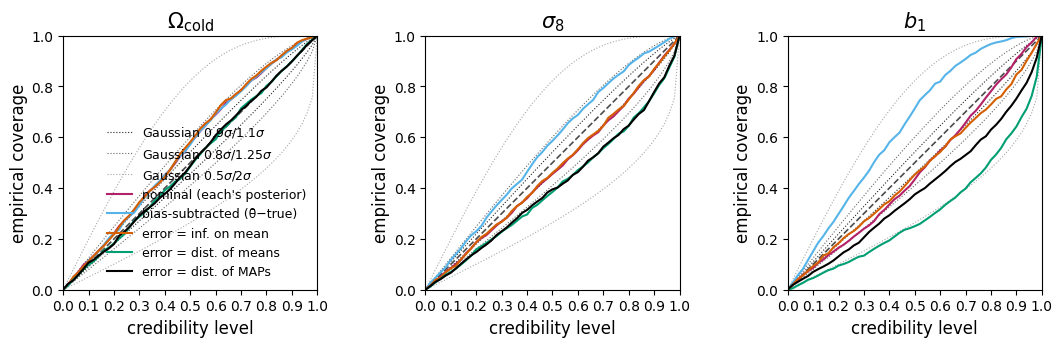

In [11]:
# g: compute alternate-error PPs and overlay (full combo)
assert list(PARAM_NAMES_ZOOM) == list(param_names_plot)
n_cols_pp = len(PARAM_NAMES_ZOOM)
n_draw_gauss = 5000
rng_pp = np.random.default_rng(42)

i_full = labels_a1d_ok.index(get_stat_label_short(STATISTICS_FULL))
pp_nominal_full = pp_emp_a1d[i_full]  # (n_cols, n_cred)


def pp_from_samples_3d(samples_phys, truth_phys):
    # samples_phys: (n_draw, n_obs, n_par); truth_phys: (n_par,)
    pp = np.full((n_cols_pp, cred_levels.size), np.nan)
    n_ok = samples_phys.shape[1]
    for c in range(n_cols_pp):
        truth_c = np.full(n_ok, truth_phys[c])
        pp[c] = emp_coverage(ranks_of_truth(samples_phys[:, :, c], truth_c))
    return pp


# bias-subtracted: remove overall location bias (mean of means − truth), keep widths
theta_bar_pp = np.nanmean(theta_hat, axis=0)
bias_pp = theta_bar_pp - theta_true
samples_debiased = samples_zoom_ok - bias_pp[None, None, :]
pp_debiased = pp_from_samples_3d(samples_debiased, theta_true)
print(f"overall bias (θ̄−true): {bias_pp}")

# error = inf-on-mean (recentred template)
samples_synth_meanerr = recentre_template(samples_mean_zoom, theta_hat)
pp_meanerr = pp_from_samples_3d(samples_synth_meanerr, theta_true)

# error = dist. of means
samples_synth_meandist = np.empty((n_draw_gauss, n_obs_ok, n_cols_pp), dtype=float)
for c in range(n_cols_pp):
    samples_synth_meandist[:, :, c] = gaussian_rank_samples(
        theta_hat[:, c], sigma_means_dist[c],
        n_draw=n_draw_gauss, rng=rng_pp,
    )
pp_meandist = pp_from_samples_3d(samples_synth_meandist, theta_true)

# error = dist. of MAPs
samples_synth_mapdist = np.empty((n_draw_gauss, n_obs_ok, n_cols_pp), dtype=float)
for c in range(n_cols_pp):
    samples_synth_mapdist[:, :, c] = gaussian_rank_samples(
        theta_map[:, c], sigma_maps_dist[c],
        n_draw=n_draw_gauss, rng=rng_pp,
    )
pp_mapdist = pp_from_samples_3d(samples_synth_mapdist, theta_true)

print("σ_meanstat:", sigma_mean_stat)
print("σ(means):  ", sigma_means_dist)
print("σ(MAPs):   ", sigma_maps_dist)

pp_all = np.stack(
    [pp_nominal_full, pp_debiased, pp_meanerr, pp_meandist, pp_mapdist], axis=0,
)
plot_pp_overlay(
    pp_all,
    colors=[COLOR_FULL, "#56B4E9", "#D55E00", "#009E73", "#000000"],
    labels=[
        r"nominal (each's posterior)",
        r"bias-subtracted (θ̄−true)",
        r"error = inf. on mean",
        r"error = dist. of means",
        r"error = dist. of MAPs",
    ],
    save_name="fig_g_pp_error_calibration_overlay",
    sigma_scale_refs=(0.5, 0.8, 0.9, 1.1, 1.25, 2.0),
)


## h. Binned prediction bias with $\pm\langle\sigma\rangle$ (coverage & CV)

Fig.~4-style binned $\Delta\theta=\theta^{\mathrm{pred}}-\theta^{\mathrm{true}}$ for the **full** statistic combo only, with horizontal $\pm\langle\sigma\rangle$ lines from (i) coverage-set posterior widths and (ii) cosmic-variance (fixed-cosmo) posterior widths.

Blue point: median $\pm$ std of $\Delta\theta$ over the cosmic-variance mocks, placed at the fixed true parameter values.



In [12]:
# Shared arrays: coverage (full combo) + CV means/sigmas
n_bins_fig4 = 10
n_inner = 250
idx_full = STATISTICS_ARR_FID.index(STATISTICS_FULL)  # full Pgg+Bggg+Pgm

# Prior bounds for innermost-N selection (match paper notebook extents)
PRIOR_BOUNDS_KEY = {
    "omega_cold": [0.23, 0.4],
    "sigma8_cold": [0.65, 0.9],
    "b1": [-1.0, 3.0],
}


def _param_latex_body(pn):
    s = param_label_dict[pn]
    return s[1:-1] if s.startswith("$") and s.endswith("$") else s


def _build_fig4_coverage_arrays():
    tags_inf, _, _, tags_test, keep, cosmo_vary, bias_vary, param_vary = setup_coverage_test()
    tags_test_ok = [tags_test[i] for i, k in enumerate(keep) if k]
    tags_inf_ok = [tags_inf[i] for i, k in enumerate(keep) if k]
    stats_ok = [STATISTICS_ARR_FID[i] for i, k in enumerate(keep) if k]
    theta_true_arr, theta_pred_arr, _, covs_pred_arr, _ = utils_plot.load_test_predictions(
        tags_inf=tags_inf_ok,
        tags_data_test=tags_test_ok,
        tag_params_test=TAG_PARAMS_TEST_COV,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
        param_names_vary=param_vary,
        tag_reparam=tag_reparam,
        param_names_show=param_names_key_rp,
    )
    theta_true_arr, theta_pred_arr, covs_pred_arr = filter_finite_coverage_rows(
        theta_true_arr, theta_pred_arr, covs_pred_arr,
    )
    theta_pred_u = theta_pred_arr.copy()
    theta_true_u = theta_true_arr.copy()
    covs_u = covs_pred_arr.copy()
    names_u = list(param_names_key_rp)
    for r in range(len(stats_ok)):
        tp, tt, covs, names_u = utils_inference.unreparameterize_prediction_block(
            theta_pred_u[r], theta_true_u[r], list(param_names_key_rp), covs_u[r],
        )
        theta_pred_u[r], theta_true_u[r], covs_u[r] = tp, tt, covs
    return {
        "theta_pred_u": theta_pred_u,
        "theta_true_u": theta_true_u,
        "covs_u": covs_u,
        "names_u": names_u,
        "stats_ok": stats_ok,
    }


_fig4 = load_or_build("fig4_coverage_arrays", _build_fig4_coverage_arrays)
theta_pred_cov = np.asarray(_fig4["theta_pred_u"][idx_full], dtype=float)
theta_true_cov = np.asarray(_fig4["theta_true_u"][idx_full], dtype=float)
covs_cov = np.asarray(_fig4["covs_u"][idx_full], dtype=float)
names_cov = list(_fig4["names_u"])
idxs_plot = [names_cov.index(pn) for pn in PARAM_NAMES_ZOOM]

delta_cov = theta_pred_cov[:, idxs_plot] - theta_true_cov[:, idxs_plot]
sigma_cov_i = np.sqrt(np.diagonal(covs_cov, axis1=-2, axis2=-1))[:, idxs_plot]
sigma_cov_bar = np.nanmean(sigma_cov_i, axis=0)

# Cosmic variance (fixed-cosmo) from shared loads
delta_cv = theta_hat - theta_true[None, :]
sigma_cv_bar = np.nanmean(sigma_hat_i, axis=0)

# Innermost n_inner coverage points in normalized (Ωc, σ8, b1) prior space
_bounds = np.array([PRIOR_BOUNDS_KEY[pn] for pn in PARAM_NAMES_ZOOM], dtype=float)
_center = 0.5 * (_bounds[:, 0] + _bounds[:, 1])
_scale = 0.5 * (_bounds[:, 1] - _bounds[:, 0])
_true_key = theta_true_cov[:, idxs_plot]
_dist3d = np.sqrt(np.sum(((_true_key - _center) / _scale) ** 2, axis=1))
idxs_inner = np.argsort(_dist3d)[:n_inner]
mask_inner = np.zeros(_true_key.shape[0], dtype=bool)
mask_inner[idxs_inner] = True
delta_cov_inner = delta_cov[mask_inner]
sigma_cov_bar_inner = np.nanmean(sigma_cov_i[mask_inner], axis=0)

print(f"coverage full combo: n={delta_cov.shape[0]}")
print(f"  ⟨σ⟩_cov:   {sigma_cov_bar}")
print(f"  ⟨σ⟩_inner: {sigma_cov_bar_inner}  (n={n_inner}, max norm dist={_dist3d[idxs_inner].max():.3f})")
print(f"CV fixed-cosmo: n={delta_cv.shape[0]}")
print(f"  ⟨σ⟩_cv:    {sigma_cv_bar}")
print(f"  std(Δ)_cov: {np.nanstd(delta_cov, axis=0, ddof=1)}")
print(f"  std(Δ)_cv:  {np.nanstd(delta_cv, axis=0, ddof=1)}")


Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/fig4_coverage_arrays.pkl
coverage full combo: n=1000
  ⟨σ⟩_cov:   [0.01591397 0.02299001 0.06364224]
  ⟨σ⟩_inner: [0.01532162 0.02061845 0.06258197]  (n=250, max norm dist=0.783)
CV fixed-cosmo: n=1000
  ⟨σ⟩_cv:    [0.0144691  0.01209918 0.01882316]
  std(Δ)_cov: [0.01901769 0.03204289 0.08190526]
  std(Δ)_cv:  [0.01212296 0.00993055 0.01120348]


/tmp/ipykernel_3626161/3214794740.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=3.0)


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_h_coverage_vs_cv_binned_diff_sigma.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_h_coverage_vs_cv_binned_diff_sigma.png


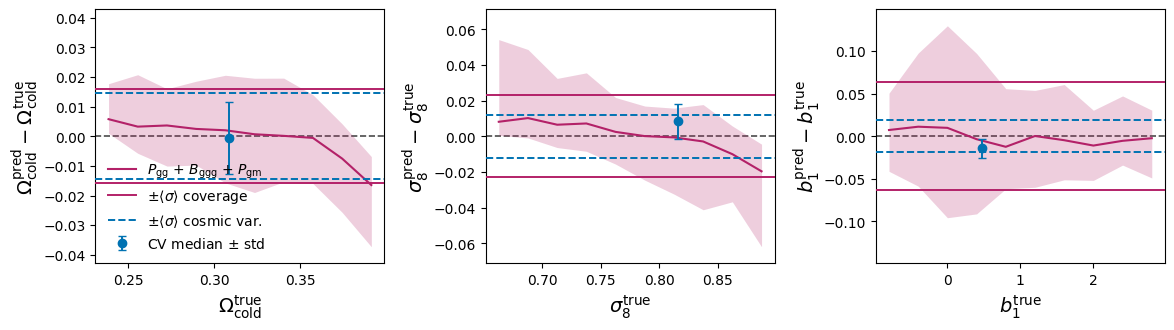

In [13]:
# h: binned Δθ vs true + ±⟨σ⟩ lines (coverage & CV)
n_cols = len(PARAM_NAMES_ZOOM)
fig, axes = plt.subplots(
    1, n_cols, figsize=(4.6 * n_cols, 3.3),
    gridspec_kw={"wspace": 0.35},
)
axes = np.atleast_1d(axes)

color_cov_sig = COLOR_FULL
color_cv_sig = "#0072B2"
lw_sig = 1.4

for c, pp in enumerate(idxs_plot):
    ax = axes[c]
    body = _param_latex_body(PARAM_NAMES_ZOOM[c])

    true_vals = theta_true_cov[:, pp]
    y_vals = delta_cov[:, c]
    ok = np.isfinite(true_vals) & np.isfinite(y_vals)
    x, y = true_vals[ok], y_vals[ok]
    edges = np.linspace(np.min(x), np.max(x), n_bins_fig4 + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    medians = np.full(n_bins_fig4, np.nan)
    p16s = np.full(n_bins_fig4, np.nan)
    p84s = np.full(n_bins_fig4, np.nan)
    for i in range(n_bins_fig4):
        m = (x >= edges[i]) & (x < edges[i + 1] if i < n_bins_fig4 - 1 else x <= edges[i + 1])
        if np.count_nonzero(m) == 0:
            continue
        p16, med, p84 = np.percentile(y[m], [16, 50, 84])
        medians[i], p16s[i], p84s[i] = med, p16, p84

    # CV: median ± std of Δ at fixed true cosmology
    d_cv = delta_cv[:, c]
    d_cv_ok = d_cv[np.isfinite(d_cv)]
    med_cv = float(np.median(d_cv_ok))
    std_cv = float(np.std(d_cv_ok, ddof=1))
    x_cv = float(theta_true[c])

    finite = np.isfinite(medians)
    half = max(
        float(np.nanmax(np.abs(p16s[finite]))) if np.any(finite) else 0.0,
        float(np.nanmax(np.abs(p84s[finite]))) if np.any(finite) else 0.0,
        float(sigma_cov_bar[c]),
        float(sigma_cv_bar[c]),
        abs(med_cv) + std_cv,
    )

    ax.axhline(0.0, color="k", ls="--", lw=1.2, alpha=0.7, zorder=1)
    if np.any(finite):
        ax.fill_between(
            centers[finite], p16s[finite], p84s[finite],
            color=COLOR_FULL, alpha=0.22, linewidth=0, zorder=2,
        )
        ax.plot(
            centers[finite], medians[finite],
            color=COLOR_FULL, lw=1.5,
            label=get_stat_label_short(STATISTICS_FULL) if c == 0 else None,
            zorder=3,
        )

    # ±⟨σ⟩ horizontal lines
    for sign in (+1.0, -1.0):
        ax.axhline(
            sign * sigma_cov_bar[c], color=color_cov_sig, lw=lw_sig, ls="-",
            zorder=4,
            label=r"$\pm\langle\sigma\rangle$ coverage" if (c == 0 and sign > 0) else None,
        )
        ax.axhline(
            sign * sigma_cv_bar[c], color=color_cv_sig, lw=lw_sig, ls="--",
            zorder=4,
            label=r"$\pm\langle\sigma\rangle$ cosmic var." if (c == 0 and sign > 0) else None,
        )

    ax.errorbar(
        x_cv, med_cv, yerr=std_cv,
        fmt="o", color=color_cv_sig, markersize=6, capsize=3, lw=1.4,
        zorder=5,
        label=r"CV median $\pm$ std" if c == 0 else None,
    )

    ax.set_ylim(-1.15 * max(half, 1e-12), 1.15 * max(half, 1e-12))
    ax.set_xlabel(rf"${body}^{{\mathrm{{true}}}}$", fontsize=14)
    ax.set_ylabel(
        rf"${body}^{{\mathrm{{pred}}}} - {body}^{{\mathrm{{true}}}}$",
        fontsize=14, labelpad=1.5,
    )
    if c == 0:
        ax.legend(fontsize=10, loc="lower left", frameon=False, labelcolor="black")

plt.tight_layout(w_pad=3.0)
save_figure(fig, "fig_h_coverage_vs_cv_binned_diff_sigma")
plt.show()


## i. $\Delta\theta$ histograms including $\sigma_8 b_1$

Coverage (full + innermost) and cosmic-variance $\Delta\theta$ histograms with an extra panel for $\sigma_8 b_1$ (Jacobian append after unreparameterization for coverage; product of unreparameterized posterior samples for CV). Shaded regions mark the symmetrized inner 68%.

The CV plot (next cell) overlays the pink inference-on-the-mean posterior shifted by $-\theta_{\mathrm{true}}$, with vertical lines under the curve marking its symmetrized inner 68%.


/tmp/ipykernel_3626161/3348403765.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_i_delta_hists_coverage_x_b1s8.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_i_delta_hists_coverage_x_b1s8.png


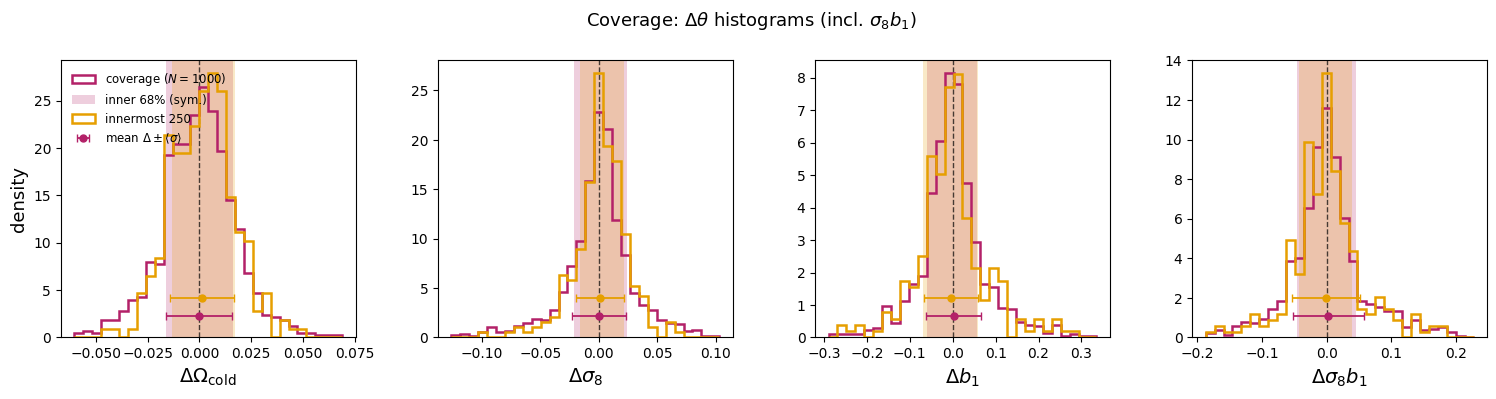

In [20]:
# Shared Δθ-histogram helper
n_cols = len(PARAM_NAMES_ZOOM)
n_bins_hist = 30
color_cov = COLOR_FULL
color_inner = "#E69F00"
color_cv = "#0072B2"
lw_h = 1.8


def _symmetrized_inner68(d):
    """Median-centered half-width with exactly ~68% of samples inside."""
    d = np.asarray(d, dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return np.nan, np.nan
    center = float(np.median(d))
    half = float(np.percentile(np.abs(d - center), 68.0))
    return center - half, center + half


def _plot_delta_hists(
    datasets, *, save_name, title=None, param_names=None, overlay=None,
):
    """datasets: list of (label, delta (n, n_par), sigma_bar (n_par,), color).
    overlay: optional (label, delta (n_samp, n_par), color) — e.g. inf-on-mean.
    """
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    n_cols_plot = len(param_names)
    fig, axes = plt.subplots(
        1, n_cols_plot, figsize=(4.6 * n_cols_plot, 3.6),
        gridspec_kw={"wspace": 0.28},
    )
    axes = np.atleast_1d(axes)

    for c in range(n_cols_plot):
        ax = axes[c]
        body = _param_latex_body(param_names[c])
        series = [
            (label, d_arr[:, c], float(sig_arr[c]), color)
            for label, d_arr, sig_arr, color in datasets
        ]

        all_parts = [d[np.isfinite(d)] for _, d, _, _ in series]
        if overlay is not None:
            _, d_ov, _ = overlay
            all_parts.append(np.asarray(d_ov[:, c], dtype=float))
        all_d = np.concatenate([p for p in all_parts if p.size])
        lo, hi = np.percentile(all_d, [0.5, 99.5])
        pad = 0.05 * (hi - lo + 1e-12)
        bins = np.linspace(lo - pad, hi + pad, n_bins_hist + 1)

        dens_max = 0.0
        means_sigmas = []
        for label, d_raw, sig_bar, color in series:
            d = d_raw[np.isfinite(d_raw)]
            h, _ = np.histogram(d, bins=bins, density=True)
            dens_max = max(dens_max, float(np.max(h)) if h.size else 0.0)

            ax.hist(
                d, bins=bins, histtype="step", density=True,
                color=color, lw=lw_h,
                label=label if c == 0 else None,
                zorder=3,
            )
            # Exact symmetrized inner 68% (continuous axvspan, not bin-aligned)
            x0, x1 = _symmetrized_inner68(d)
            if np.isfinite(x0) and np.isfinite(x1) and x1 > x0:
                ax.axvspan(
                    x0, x1,
                    color=color, alpha=0.22, lw=0, zorder=1,
                    label=r"inner 68% (sym.)" if (c == 0 and color == series[0][3]) else None,
                )
            means_sigmas.append((float(np.mean(d)), sig_bar, color))

        if overlay is not None:
            from scipy.stats import gaussian_kde
            ov_label, d_ov, ov_color = overlay
            d_o = np.asarray(d_ov[:, c], dtype=float)
            d_o = d_o[np.isfinite(d_o)]
            if d_o.size > 1 and np.nanstd(d_o) > 0:
                # Smooth 1D marginal (KDE), matching contour-plot style
                x_grid = np.linspace(bins[0], bins[-1], 400)
                kde = gaussian_kde(d_o)
                y_kde = kde(x_grid)
                dens_max = max(dens_max, float(np.max(y_kde)))
                ax.plot(
                    x_grid, y_kde,
                    color=ov_color, lw=lw_h + 0.3,
                    label=ov_label if c == 0 else None,
                    zorder=4,
                )
                # Vertical lines under pink curve at symmetrized inner 68%
                x0, x1 = _symmetrized_inner68(d_o)
                if np.isfinite(x0) and np.isfinite(x1) and x1 > x0:
                    y0 = float(kde(np.array([x0]))[0])
                    y1 = float(kde(np.array([x1]))[0])
                    ax.vlines(
                        [x0, x1], 0.0, [y0, y1],
                        colors=ov_color, lw=1.6, zorder=4,
                        label=r"inf. on mean inner 68%" if c == 0 else None,
                    )

        ax.axvline(0.0, color="k", ls="--", lw=1.0, alpha=0.7, zorder=2)

        y_base = 0.08 * dens_max if dens_max > 0 else 0.01
        y_step = 0.07 * dens_max if dens_max > 0 else 0.01
        for i_s, (mu, sig, color) in enumerate(means_sigmas):
            ax.errorbar(
                mu, y_base + i_s * y_step, xerr=sig,
                fmt="o", color=color, markersize=5, capsize=3, lw=1.3,
                zorder=5,
                label=r"mean $\Delta\pm\langle\sigma\rangle$" if (c == 0 and i_s == 0) else None,
            )

        ax.set_xlabel(rf"$\Delta {body}$", fontsize=14)
        if c == 0:
            ax.set_ylabel("density", fontsize=13)
            ax.legend(fontsize=8.5, loc="upper left", frameon=False, labelcolor="black")

    if title:
        fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    save_figure(fig, save_name)
    plt.show()

# i: Δθ histograms incl. σ₈ b₁ — coverage (+ shared helper / arrays)
PARAM_NAMES_PLOT = utils_plot.get_param_names_key_plot()  # + sigma8_cold_x_b1

# --- Coverage: append σ₈×b₁ via Jacobian on unreparameterized means/covs ---
_tp_x, _names_x, _covs_x = utils_plot.append_sigma8_cold_x_b1(
    theta_pred_cov, names_cov, covs_cov,
)
_tt_x, _, _ = utils_plot.append_sigma8_cold_x_b1(
    theta_true_cov, names_cov, None,
)
idxs_plot_x = [_names_x.index(pn) for pn in PARAM_NAMES_PLOT]
delta_cov_x = _tp_x[:, idxs_plot_x] - _tt_x[:, idxs_plot_x]
sigma_cov_i_x = np.sqrt(np.diagonal(_covs_x, axis1=-2, axis2=-1))[:, idxs_plot_x]
sigma_cov_bar_x = np.nanmean(sigma_cov_i_x, axis=0)
delta_cov_inner_x = delta_cov_x[mask_inner]
sigma_cov_bar_inner_x = np.nanmean(sigma_cov_i_x[mask_inner], axis=0)

# --- CV: product from unreparameterized posterior samples ---
i_s8 = PARAM_NAMES_ZOOM.index("sigma8_cold")
i_b1 = PARAM_NAMES_ZOOM.index("b1")
prod_samps = samples_zoom_ok[:, :, i_s8] * samples_zoom_ok[:, :, i_b1]
theta_hat_prod = np.nanmean(prod_samps, axis=0)
sigma_prod_i = np.nanstd(prod_samps, axis=0)
theta_true_prod = float(theta_true[i_s8] * theta_true[i_b1])
delta_cv_x = np.column_stack([delta_cv, theta_hat_prod - theta_true_prod])
sigma_cv_bar_x = np.append(sigma_cv_bar, np.nanmean(sigma_prod_i))

# --- Inf-on-mean posterior shifted from truth (pink overlay on CV) ---
delta_mean_zoom = samples_mean_zoom - theta_true[None, :]
delta_mean_prod = (
    samples_mean_zoom[:, i_s8] * samples_mean_zoom[:, i_b1] - theta_true_prod
)
delta_mean_x = np.column_stack([delta_mean_zoom, delta_mean_prod])
overlay_mean = (
    r"inf. on mean ($-\theta_{\mathrm{true}}$)",
    delta_mean_x,
    COLOR_FULL,
)

n_cov_x = int(np.sum(np.all(np.isfinite(delta_cov_x), axis=1)))
n_cv_x = int(np.sum(np.all(np.isfinite(delta_cv_x), axis=1)))

_plot_delta_hists(
    [
        (rf"coverage ($N={n_cov_x}$)", delta_cov_x, sigma_cov_bar_x, color_cov),
        (rf"innermost {n_inner}", delta_cov_inner_x, sigma_cov_bar_inner_x, color_inner),
    ],
    save_name="fig_i_delta_hists_coverage_x_b1s8",
    title=r"Coverage: $\Delta\theta$ histograms (incl. $\sigma_8 b_1$)",
    param_names=PARAM_NAMES_PLOT,
)


/tmp/ipykernel_3626161/3348403765.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-06_error_calibration_check/fig_i_delta_hists_cv_x_b1s8.png
Saved: /home/kstoreyf/muchisimocks/figures/error_calibration_check_latest/fig_i_delta_hists_cv_x_b1s8.png


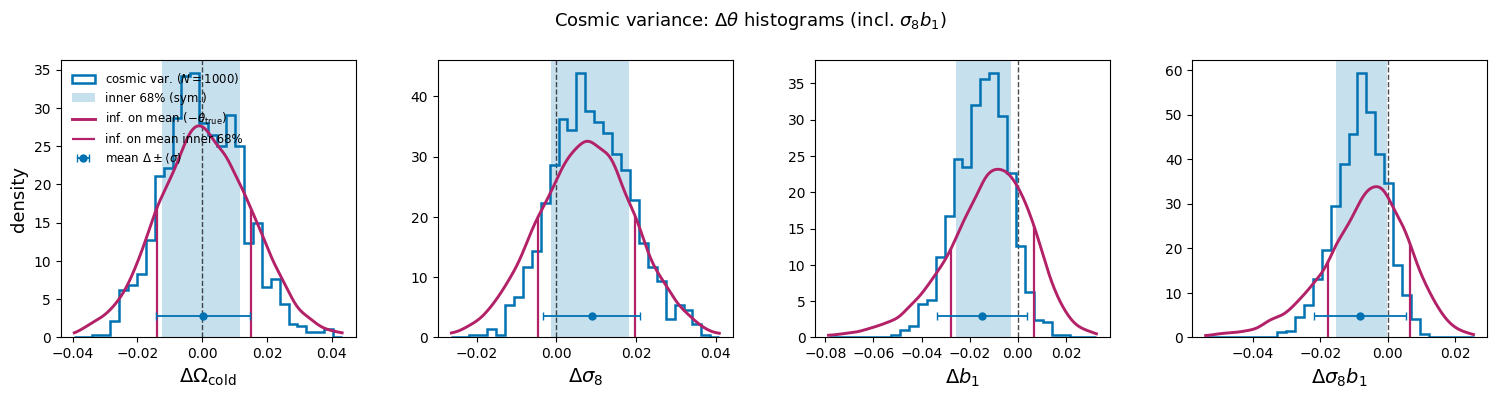

In [21]:
# i (cont.): CV Δθ histograms with inf-on-mean overlay
_plot_delta_hists(
    [
        (rf"cosmic var. ($N={n_cv_x}$)", delta_cv_x, sigma_cv_bar_x, color_cv),
    ],
    save_name="fig_i_delta_hists_cv_x_b1s8",
    title=r"Cosmic variance: $\Delta\theta$ histograms (incl. $\sigma_8 b_1$)",
    param_names=PARAM_NAMES_PLOT,
    overlay=overlay_mean,
)


## j. PP plot — cosmic variance including $\sigma_8 b_1$

Fixed-cosmo (cosmic-variance) suite as in (d), all available statistic combinations. Panels: $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$, and $\sigma_8 b_1$ (NPE coordinate).

Below: **mean-subtracted** — for each combo, shift every posterior by $-(\bar\theta-\theta_{\mathrm{true}})$ where $\bar\theta$ is the mean of that combo's per-realization posterior means, then recompute PP (removes overall location bias; widths unchanged).



In [ ]:
# j: CV PP with σ₈b₁ (all available combos) + mean-subtracted below
PARAM_NAMES_PP_X = utils_plot.get_param_names_key_plot()  # Ωc, σ8, b1, σ8b1
n_cols_pp_x = len(PARAM_NAMES_PP_X)

tags_inf_l, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=STATISTICS_ARR_FID,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=TAGS_MASK_FID,
)
tags_inf_l = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_l]
tag_stats_l = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
tags_test_l = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
    tag_stats_arr=tag_stats_l,
    tag_noise_test=TAG_NOISE_TEST_FIXED,
    tag_datagen_test="",
    tags_mask_test=TAGS_MASK_FID,
)
keep_l = samples_exist(tags_inf_l, tags_test_l)
tags_inf_l_ok = [tags_inf_l[i] for i, k in enumerate(keep_l) if k]
tags_test_l_ok = [tags_test_l[i] for i, k in enumerate(keep_l) if k]
colors_l_ok = [COLORS_FID[i] for i, k in enumerate(keep_l) if k]
labels_l_ok = [get_stat_label_short(STATISTICS_ARR_FID[i]) for i, k in enumerate(keep_l) if k]
missing_l = [
    get_stat_label_short(STATISTICS_ARR_FID[i])
    for i, k in enumerate(keep_l) if not k
]
print(f"PP CV + σ8b1: {len(tags_inf_l_ok)}/{len(STATISTICS_ARR_FID)} combos with samples")
if missing_l:
    print(f"  missing individual-realization samples: {missing_l}")

cosmo_vary_l, bias_vary_l, param_vary_l = utils_plot.load_training_params(
    TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
)
theta_fixed_l = data_loader.load_theta_test(
    TAG_PARAMS_TEST_FIXED,
    TAG_BIASPARAMS_TEST_FIXED,
    cosmo_param_names_vary=cosmo_vary_l,
    bias_param_names_vary=bias_vary_l,
)
theta_fixed_l_2d = np.atleast_2d(np.asarray(theta_fixed_l, dtype=float))
if tag_reparam:
    theta_fixed_rp_l, names_theta_l = utils_inference.reparameterize_theta(
        theta_fixed_l_2d, list(param_vary_l),
    )
else:
    theta_fixed_rp_l, names_theta_l = theta_fixed_l_2d, list(param_vary_l)
names_theta_l = list(names_theta_l)
i_t_l = [names_theta_l.index(pn) for pn in names_need_rp]
theta_phys_fixed_l = physical_from_rp(theta_fixed_rp_l[0, i_t_l])
truth_pp_x = np.array(
    [
        float(theta_phys_fixed_l[0]),
        float(theta_phys_fixed_l[1]),
        float(theta_phys_fixed_l[2]),
        float(theta_fixed_rp_l[0, i_t_l[2]]),  # σ8 × b1
    ],
    dtype=float,
)
print(f"fixed truth (Ωc, σ8, b1, σ8b1) = {truth_pp_x}")


def _load_key_samples_l(tag_inf, tag_test):
    dir_run = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}"
    fn = dir_run / f"samples_test{tag_test}_pred.npy"
    names_samp = list(np.loadtxt(dir_run / "param_names.txt", dtype=str))
    idxs = [names_samp.index(pn) for pn in names_need_rp]
    mm = np.load(fn, mmap_mode="r")
    if mm.ndim == 2:
        return np.asarray(mm[:, idxs], dtype=np.float64)[:, None, :]
    return np.asarray(mm[:, :, idxs], dtype=np.float64)


def _samples_pp_x(tag_inf, tag_test):
    """(n_draw, n_obs_ok, 4): physical Ωc,σ8,b1 + rp σ8b1."""
    samples_rp = _load_key_samples_l(tag_inf, tag_test)
    ok = np.all(np.isfinite(samples_rp.mean(axis=0)), axis=1)
    samples_rp = samples_rp[:, ok, :]
    samples_phys = physical_from_rp(samples_rp)
    return np.concatenate([samples_phys, samples_rp[:, :, 2:3]], axis=-1), ok


def _pp_from_samples_4(samples_4, truth_4):
    n_ok = samples_4.shape[1]
    pp = np.full((n_cols_pp_x, cred_levels.size), np.nan)
    for c in range(n_cols_pp_x):
        truth_c = np.full(n_ok, truth_4[c])
        pp[c] = emp_coverage(ranks_of_truth(samples_4[:, :, c], truth_c))
    return pp


def _build_fig_j_pp_emp_x():
    n_rows = len(tags_inf_l_ok)
    pp = np.full((n_rows, n_cols_pp_x, cred_levels.size), np.nan)
    for r in range(n_rows):
        samples_4, ok = _samples_pp_x(tags_inf_l_ok[r], tags_test_l_ok[r])
        print(f"  nominal {labels_l_ok[r]}: {samples_4.shape[1]}/{ok.size} usable")
        pp[r] = _pp_from_samples_4(samples_4, truth_pp_x)
    return pp


def _build_fig_j_pp_emp_x_meansub():
    n_rows = len(tags_inf_l_ok)
    pp = np.full((n_rows, n_cols_pp_x, cred_levels.size), np.nan)
    for r in range(n_rows):
        samples_4, ok = _samples_pp_x(tags_inf_l_ok[r], tags_test_l_ok[r])
        theta_hat = np.nanmean(samples_4, axis=0)  # (n_obs, 4)
        bias = np.nanmean(theta_hat, axis=0) - truth_pp_x
        samples_deb = samples_4 - bias[None, None, :]
        print(f"  mean-sub {labels_l_ok[r]}: bias={bias}, n={samples_4.shape[1]}")
        pp[r] = _pp_from_samples_4(samples_deb, truth_pp_x)
    return pp


pp_emp_cv_x = load_or_build("fig_j_cv_pp_emp_x_arr", _build_fig_j_pp_emp_x)
plot_pp_overlay(
    pp_emp_cv_x,
    colors=colors_l_ok,
    labels=labels_l_ok,
    param_names=PARAM_NAMES_PP_X,
    save_name="fig_j_cosmic_variance_pp_x_b1s8",
)

pp_emp_cv_x_ms = load_or_build(
    "fig_j_cv_pp_emp_x_meansub_arr", _build_fig_j_pp_emp_x_meansub,
)
plot_pp_overlay(
    pp_emp_cv_x_ms,
    colors=colors_l_ok,
    labels=labels_l_ok,
    param_names=PARAM_NAMES_PP_X,
    save_name="fig_j_cosmic_variance_pp_x_b1s8_meansub",
    title_suffix=r"(mean-subtracted)",
)

